# ConvDenoiser — Training and Evaluation

Trains a dilated residual 1D convolutional denoiser on each of the 13 perturbation datasets and compares accuracy against argmax and the base per-position MLP.

**Architecture**: 6 dilated residual blocks with dilations [1, 2, 4, 8, 16, 32], kernel size 3.  
**Receptive field**: 127 positions.  
**Parameters**: ~600k (d=128).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.conv_denoiser import ConvDenoiser
from models.single_shot import make_loaders, run_epoch
from models.properties import AA_ORDER

## Configuration

In [2]:
H5_PATH  = Path('../data/synthetic/perturbed_n1000_seed42.h5')
CKPT_DIR = Path('../models/checkpoints')

DATASETS = [
    'ground_truth',
    'perturb_gamma50', 'perturb_gamma10', 'perturb_gamma3', 'perturb_gamma1',
    'scramble_1pct', 'scramble_5pct', 'scramble_10pct', 'scramble_20pct',
    'lowconf_1pct', 'lowconf_5pct', 'lowconf_10pct', 'lowconf_20pct',
]

EPOCHS     = 30
BATCH_SIZE = 32
LR         = 1e-3
D          = 128       # channel width; use 64 for a lighter model
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

aa_to_idx = {aa: i for i, aa in enumerate(AA_ORDER)}
print(f'Device: {DEVICE}')

Device: cpu


## Base MLP results (reference)

Pre-computed from `train_single_shot.ipynb`.

In [3]:
BASE_MLP = {
    'ground_truth':    1.00000, 'perturb_gamma50': 1.00000,
    'perturb_gamma10': 0.99997, 'perturb_gamma3':  0.99542,
    'perturb_gamma1':  0.96827, 'scramble_1pct':   0.99043,
    'scramble_5pct':   0.95259, 'scramble_10pct':  0.90499,
    'scramble_20pct':  0.80995, 'lowconf_1pct':    0.99127,
    'lowconf_5pct':    0.95610, 'lowconf_10pct':   0.91163,
    'lowconf_20pct':   0.82413,
}

## Helper: argmax accuracy

In [4]:
def argmax_accuracy(h5_path, dataset_key, val_pids):
    correct = total = 0
    with h5py.File(h5_path, 'r') as f:
        for pid in val_pids:
            p   = f[pid][dataset_key][()].astype(np.float32)
            seq = f[pid]['sequence'][()].decode()
            pred = p.argmax(axis=1)
            true = np.array([aa_to_idx[aa] for aa in seq])
            correct += (pred == true).sum()
            total   += len(true)
    return correct / total

## Training loop

In [5]:
records = []

for key in DATASETS:
    train_loader, val_loader, _, val_pids = make_loaders(
        H5_PATH, key, aa_to_idx,
        batch_size=BATCH_SIZE, val_frac=0.2, seed=42,
    )

    model = ConvDenoiser(d=D).to(DEVICE)
    model.fit_stats(train_loader, device=DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc, best_state = 0.0, None
    for epoch in range(1, EPOCHS + 1):
        run_epoch(model, train_loader, optimizer, DEVICE, train=True)
        _, val_acc = run_epoch(model, val_loader, None, DEVICE, train=False)
        scheduler.step()
        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    torch.save(best_state, CKPT_DIR / f'conv_denoiser_{key}.pt')

    argmax_acc = argmax_accuracy(H5_PATH, key, val_pids)
    records.append({
        'dataset':   key,
        'argmax':    argmax_acc,
        'base_mlp':  BASE_MLP[key],
        'conv':      best_acc,
        'delta':     best_acc - BASE_MLP[key],
    })
    print(f"{key:<25}  argmax={argmax_acc:.3%}  base={BASE_MLP[key]:.3%}  conv={best_acc:.3%}  delta={best_acc-BASE_MLP[key]:+.3%}")

ground_truth               argmax=100.000%  base=100.000%  conv=100.000%  delta=+0.000%
perturb_gamma50            argmax=100.000%  base=100.000%  conv=100.000%  delta=+0.000%
perturb_gamma10            argmax=99.998%  base=99.997%  conv=99.994%  delta=-0.003%
perturb_gamma3             argmax=99.384%  base=99.542%  conv=99.484%  delta=-0.058%
perturb_gamma1             argmax=95.722%  base=96.827%  conv=96.948%  delta=+0.121%
scramble_1pct              argmax=99.043%  base=99.043%  conv=99.043%  delta=+0.000%
scramble_5pct              argmax=95.259%  base=95.259%  conv=95.262%  delta=+0.003%
scramble_10pct             argmax=90.499%  base=90.499%  conv=90.504%  delta=+0.005%
scramble_20pct             argmax=80.995%  base=80.995%  conv=81.038%  delta=+0.043%
lowconf_1pct               argmax=99.130%  base=99.127%  conv=99.114%  delta=-0.013%
lowconf_5pct               argmax=95.525%  base=95.610%  conv=95.556%  delta=-0.054%
lowconf_10pct              argmax=91.022%  base=91.163%  co

## Results table

In [8]:
df = pd.DataFrame(records)
df_display = df.copy()
df_display['argmax']    = df['argmax'].map('{:.3%}'.format)
df_display['base_mlp']  = df['base_mlp'].map('{:.3%}'.format)
df_display['conv']      = df['conv'].map('{:.3%}'.format)
df_display['delta']     = df['delta'].map('{:+.3%}'.format)
df_display

,dataset,argmax,base_mlp,conv,delta
0,ground_truth,100.000%,100.000%,100.000%,+0.000%
1,perturb_gamma50,100.000%,100.000%,100.000%,+0.000%
2,perturb_gamma10,99.998%,99.997%,99.994%,-0.003%
3,perturb_gamma3,99.384%,99.542%,99.484%,-0.058%
4,perturb_gamma1,95.722%,96.827%,96.948%,+0.121%
5,scramble_1pct,99.043%,99.043%,99.043%,+0.000%
6,scramble_5pct,95.259%,95.259%,95.262%,+0.003%
7,scramble_10pct,90.499%,90.499%,90.504%,+0.005%
8,scramble_20pct,80.995%,80.995%,81.038%,+0.043%
9,lowconf_1pct,99.130%,99.127%,99.114%,-0.013%


## Plot: accuracy by dataset

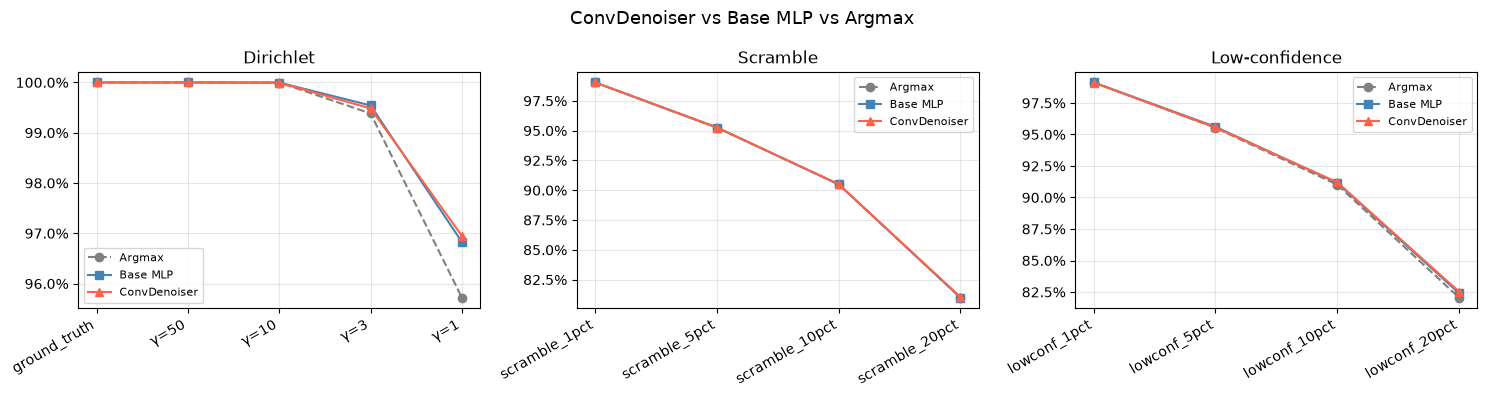

In [9]:
df_plot = pd.DataFrame(records)

groups = {
    'Dirichlet':       [k for k in DATASETS if k.startswith('perturb') or k == 'ground_truth'],
    'Scramble':        [k for k in DATASETS if k.startswith('scramble')],
    'Low-confidence':  [k for k in DATASETS if k.startswith('lowconf')],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, keys) in zip(axes, groups.items()):
    sub = df_plot[df_plot['dataset'].isin(keys)].set_index('dataset').loc[keys]
    x = range(len(sub))
    ax.plot(x, sub['argmax'],   'o--', color='grey',   label='Argmax')
    ax.plot(x, sub['base_mlp'], 's-',  color='steelblue', label='Base MLP')
    ax.plot(x, sub['conv'],     '^-',  color='tomato',  label='ConvDenoiser')
    ax.set_xticks(list(x))
    ax.set_xticklabels([k.replace('perturb_gamma', 'γ=').replace('_pct', '%') for k in keys], rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('ConvDenoiser vs Base MLP vs Argmax', fontsize=13)
plt.tight_layout()
plt.show()